In [1]:
import random
import numpy as np
import networkx as nx
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib

The basic idea of ERGM is to define a probability distribution over all possible graphs of a given number of nodes, <u>where the probability of each graph is proportional to some of its network statistics.</u> In this post, the statistics I’ll use throughout are the edge count and the number of triangles, but any network statistics will do.

If edge count and triangles have coefficients a and b, then the probability of observing a particular graph G is:
$$Pr(G)\propto e^{(a * edges(G) + b * triangles (G))}$$

Think of this as the ‘weight’ we put on a particular network. In Python, this looks like:

In [2]:
def compute_weight(G, edge_coeff, tri_coeff):
    '''
    Compute the probability weight on graph G
    '''
    edge_count = len(G.edges())
    triangles = sum(nx.triangles(G).values())
    return np.exp(edge_count * edge_coeff + triangles * tri_coeff)

To turn that weight into a probability (the probability of observing this network), we need to normalize it by the weights of all other possible networks. Mathematically:
$$Pr(G) = exp (a * edges(G) + b * triangles (G))/ \sum_{g\in{G}}exp (a * edges(g) + b * triangles (g))$$

Now we come to the first problem: calculating the denominator of that equation. There are many possible graphs. To take the simplest example, an undirected graph with 3 nodes has 8 possible configurations:
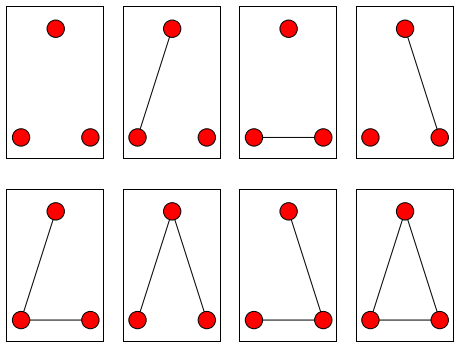

Most of the time, we simply can’t calculate the weights for all possible graphs. Instead, we need some sort of approximation. We could just generate some large number of random graphs, and use that – but we have no way of knowing how representative they are of the actual distribution. We need a way to generate a sample that we think covers the most probable area of the distribution. In terms of the equation above, we want to sample heavily from networks where the weights are large, and less where the weights are small, so that the sum of the weights of the sample gets as close as possible to the actual total weight. Which brings us to the next step:

### Markov Chain Monte Carlo
Markov Chain Monte Carlo (MCMC) actually refers a broad class of techniques for generating samples from complicated distributions. For our purposes, it means exploring the space of possible networks, moving toward the ones which are more likely given the distribution coefficients.

We’ll implement a simple version of the Metropolis-Hastings algorithm. We start with some network, and randomly add or subtract an edge.

In [47]:
def permute_graph(G):
    '''
    Return a new graph with an edge randomly added or subtracted from G
    '''
    G1 = G.copy()
    d = nx.density(G1)
    r = random.random()
    if (r < 0.5 or d == 0) and d != 1:
        # Add an edge
        nodes = list(G.nodes())
        n1 = random.choice(nodes)
        n2 = random.choice(nodes)
        G1.add_edge(n1, n2)
    else:
        # Remove an edge
        n1, n2 = random.choice(list(G1.edges()))
        G1.remove_edge(n1, n2)
    return G1

After the change, we check the weight on this new network. 
- If it’s greater than the previous network’s weight (that is, it’s more probable under this distribution), we accept it and add it to our sample; it is also our new ‘current’ network. 
- Otherwise, we might still accept it, deciding randomly based on the ratio between the new and old weights. 

We repeat this many times, until we decide we have enough samples. The starting network can be any graph – I found that a random network worked well for my relatively small sample sizes, but we can also use the observed network itself, or a completely empty one. In theory, it shouldn’t matter after enough iterations.

In [6]:
def mcmc(G, edge_coeff, triangle_coeff, n):
    '''
    Use MCMC to generate a sample of networks from an ERG distribution.

    Args:
        G: The observed network, to seed the graph with
        edge_coeff: The coefficient on the number of edges
        triangle_coeff: The coefficient on number of triangles
        n: The number of samples to generate
    Returns:
        A list of graph objects
    '''

    v = len(G) # number of nodes in G
    p = nx.density(G) # Probability of a random edge existing
    current_graph = nx.erdos_renyi_graph(v, p) # Random graph
    current_w = compute_weight(G, edge_coeff, triangle_coeff)
    graphs = []
    while len(graphs) < n:
        new_graph = permute_graph(current_graph)
        new_w = compute_weight(new_graph, edge_coeff, triangle_coeff)
        if new_w > current_w or random.random() < (new_w/current_w):
            graphs.append(new_graph)
            current_w = new_w
    return graphs

### Fitting the model 
The first thing we need to do is calculate the probability of observing any given graph, which means summing the weights of all the graphs in a sample:

In [7]:
def sum_weights(graphs, edge_coeff, tri_coeff):
    '''
    Sum the probability weights on every graph in graphs
    '''
    total = 0.0
    for g in graphs:
        total += compute_weight(g, edge_coeff, tri_coeff)
    return total

With this, we can calculate the probability of a given graph by dividing its weight by the sum of all weights from the sample.

Next, we can use our favorite optimization technique to hunt through the space of possible edge and triangle coefficients.

Instead of changing the network, we’ll randomly change the parameters, and use our MCMC function to estimate the probability of getting the observed network at those parameter values.

One simple way to do it uses a similar Metropolis-Hastings approach to the one we used above, with one tweak: early on, we want to try larger jumps around the parameter space; as we get further along, and hopefully closer to the ‘best’ value, the jumps should get smaller and smaller. There’s not really a right way to tweak the jump size.

In [53]:
def fit_ergm(G, coeff_samples=100, graph_samples=1000, return_all=False):
    '''
    Use MCMC to sample possible coefficients, and return the best fits.

    Args:
        G: The observed graph to fit
        coeff_samples: The number of coefficient combinations to sample
        graph_samples: The number of graphs to sample for each set of coeffs
        return_all: If True, return all sampled values. Otherwise, only best.
    Returns:
        If return_all=False, returns a tuple of values,
            (best_edge_coeff, best_triangle_coeff, best_p)
        where p is the estimated probability of observing the graph G with
        the fitted parameters.

        Otherwise, return a tuple of lists:
            (edge_coeffs, triangle_coeffs, probs)
    '''
    edge_coeffs = [0]
    triangle_coeffs = [0]
    probs = [0]

    while len(probs) < coeff_samples:
        # Make the jump size larger early on, and smaller toward the end
        w = coeff_samples/50.0
        s = np.sqrt(w/len(probs))
        # Pick new coefficients to try:
        edge_coeff = edge_coeffs[-1] +  random.normalvariate(0, s)
        triangle_coeff = triangle_coeffs[-1] + random.normalvariate(0, s)
        # Check how likely the observed graph is under this distribution:
        graphs = mcmc(G, edge_coeff, triangle_coeff, graph_samples)
        sum_weight = sum_weights(graphs, edge_coeff, triangle_coeff)
        p = compute_weight(G, edge_coeff, triangle_coeff) / sum_weight
        # Decide whether to accept the jump:
        if p > probs[-1] or random.random() < (p / probs[-1]):
            edge_coeffs.append(edge_coeff)
            triangle_coeffs.append(triangle_coeff)
            probs.append(p)
        else:
            edge_coeffs.append(edge_coeffs[-1])
            triangle_coeffs.append(triangle_coeffs[-1])
            probs.append(probs[1])
    # Return either the best values, or all of them:
    if not return_all:
        i = np.argmax(probs)
        best_p = probs[i]
        best_edge_coeff = edge_coeffs[i]
        best_triangle_coeff = triangle_coeffs[i]
        return (best_edge_coeff, best_triangle_coeff, best_p)
    else:
        return (edge_coeffs, triangle_coeffs, probs)

### Example application
Now the real test – fitting the ERGM to an actual network. The canonical example is the Florentine marriage network, which is included in NetworkX.

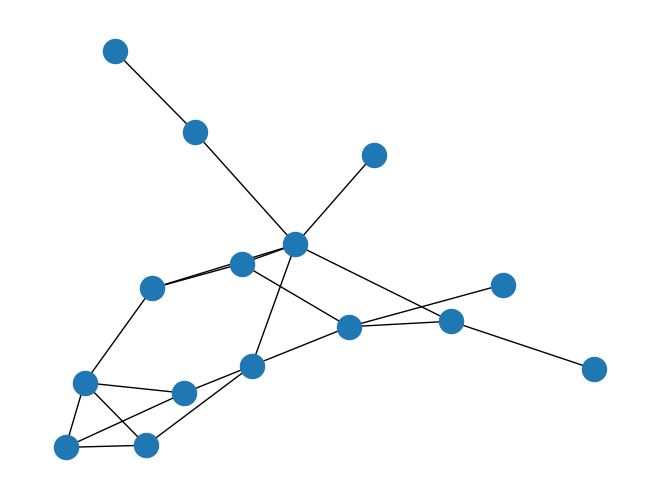

In [27]:
G = nx.florentine_families_graph()
nx.draw(G)

In [ ]:
%%timeit
edge_coeffs, triangle_coeffs, probs = fit_ergm(G, 10, 10, True)